In [1]:
import torch 
from torch import nn
from sklearn.model_selection import train_test_split
import torchvision
from torchvision import datasets 
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
device = 'mps' if torch.mps.is_available() else 'cpu'
torch.mps.manual_seed(1234)
torch.manual_seed(1234)

In [2]:
train_data = datasets.FashionMNIST(
    root='data', train=True, download=True,
    transform=ToTensor(), target_transform=None
)
test_data = datasets.FashionMNIST(
    root='data', train=False, download=True,
    transform=ToTensor(), target_transform=None
)

100%|██████████| 26.4M/26.4M [00:03<00:00, 8.51MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 168kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.42MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 19.9MB/s]


In [7]:
train_data[0][0].shape

torch.Size([1, 28, 28])

In [9]:
type(train_data)

torchvision.datasets.mnist.FashionMNIST

In [13]:
train_data.data.shape

torch.Size([60000, 28, 28])

In [14]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [20]:
train_data[0][0].squeeze().shape

torch.Size([28, 28])

In [23]:
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

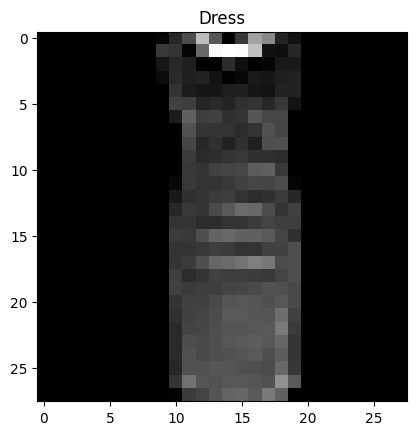

In [40]:
import random
i = random.randint(0, len(train_data))

import matplotlib.pyplot as plt
image, label = train_data[i]
plt.imshow(image.squeeze(), cmap='gray')
plt.title(class_names[label])
plt.show()

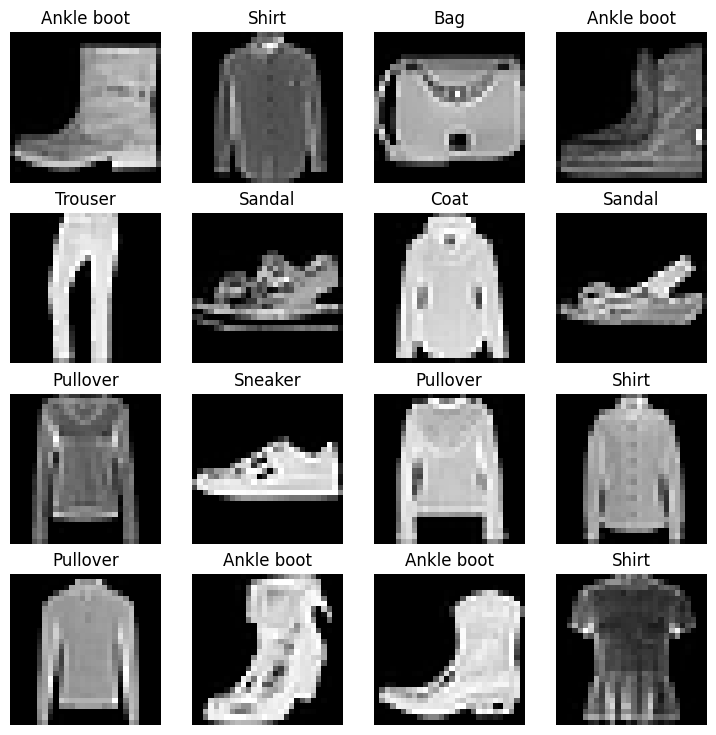

In [41]:
# Plot more images
torch.manual_seed(42)
fig = plt.figure(figsize=(9, 9))
rows, cols = 4, 4
for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis(False)

In [42]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32
train_dataloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

In [44]:
len(train_dataloader), len(test_dataloader)

(1875, 313)

### Baseline Model 

In [61]:
trial = nn.Flatten()

trial(next(iter(train_dataloader))[0]).shape

torch.Size([32, 784])

In [62]:
class model0(nn.Module):
    def __init__(self, n_input, n_output, n_hidden=10):
        super().__init__()
        self.layer_0 = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_input, n_hidden),
            nn.Linear(n_hidden, n_output)
        )

    def forward(self, x):
        return self.layer_0(x)

In [63]:
model_0 = model0(n_input=784, n_output=len(class_names), n_hidden=10)
model_0.to('cpu')

model0(
  (layer_0): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [70]:
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

def accuracy_function(y_true, y_pred):
    return (y_true == y_pred).sum()

In [77]:
epochs = 3

train_accuracies, test_accuracies = [], []
for i in range(epochs):
    overall_train_acc_counts = 0
    train_loss_total = 0
    model_0.train()
    for batch_num, (X, y) in enumerate(train_dataloader):
        train_logits = model_0(X)
        train_pred = torch.softmax(train_logits, dim=1).argmax(dim=1)
        train_acc_counts = accuracy_function(y, train_pred)
        overall_train_acc_counts += train_acc_counts

        train_loss = loss_function(train_logits, y)
        train_loss_total += train_loss.item()
        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()
    overall_test_acc_counts = 0
    test_loss_total = 0
    test_loss, test_acc_counts = 0, 0
    model_0.eval()
    with torch.inference_mode():
        for X, y in test_dataloader:
            test_logits = model_0(X)
            test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
            test_loss_total += loss_function(test_logits, y).item()

            overall_test_acc_counts += accuracy_function(test_pred, y)



    epoch_train_accuracy = (overall_train_acc_counts / len(train_data)) * 100
    epoch_test_accuracy = (overall_test_acc_counts / len(test_data)) * 100

    avg_train_loss = train_loss_total / len(train_dataloader)
    avg_test_loss = test_loss_total / len(test_dataloader)
    train_accuracies.append(epoch_train_accuracy)
    test_accuracies.append(epoch_test_accuracy)
    print(f"Epoch {i} | Train Loss: {avg_train_loss:.4f} | Train Acc: {epoch_train_accuracy:.2f}% | Test Loss: {avg_test_loss:.4f} | Test Acc: {epoch_test_accuracy:.2f}%")


Epoch 0 | Train Loss: 0.4075 | Train Acc: 85.59% | Test Loss: 0.4760 | Test Acc: 83.30%
Epoch 1 | Train Loss: 0.4072 | Train Acc: 85.65% | Test Loss: 0.4573 | Test Acc: 84.00%
Epoch 2 | Train Loss: 0.4055 | Train Acc: 85.80% | Test Loss: 0.4844 | Test Acc: 83.06%


In [88]:
def eval_model(
    model: torch.nn.Module, data_loader: torch.utils.data.DataLoader,
    loss_function: torch.nn.Module, accuracy_function    
):
    loss, acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            y_logits = model(X)
            y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)

            loss += loss_function(y_logits, y)
            acc += accuracy_function(y_true=y, y_pred=y_pred)
        
        loss /= len(data_loader)
    acc_pct = (acc / (len(data_loader) * train_dataloader.batch_size)) * 100
    return {
        'model_name': model.__class__.__name__, 'model_loss': loss.item(), 
        'model_acc': acc_pct.item()
    }

In [89]:
model_0_results = eval_model(model=model_0, data_loader=test_dataloader,
    loss_function=loss_function, accuracy_function=accuracy_function
)
model_0_results

{'model_name': 'model0',
 'model_loss': 0.48442545533180237,
 'model_acc': 82.92731475830078}

### Model 1

In [106]:
class model1(nn.Module):
    def __init__(self, n_input: int, n_output: int, n_hidden: int=128):
        super().__init__()
        self.layer_0 = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=n_input, out_features=n_hidden),
            nn.ReLU(),
            nn.Linear(in_features=n_hidden, out_features=n_output)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layer_0(x)

In [107]:
model_1 = model1(784, len(class_names), 128)
model_1.to(device)

model1(
  (layer_0): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)

In [108]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(
    params=model_1.parameters(), 
    lr=0.1
)

In [109]:
def train_step(model: torch.nn.Module, 
               data_loader: torch.utils.data.DataLoader,
               loss_function: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_function,
               device: torch.device):
    
    overall_train_acc_counts = 0
    train_loss_total = 0
    
    model.to(device)
    model.train()
    
    for batch_num, (X, y) in enumerate(data_loader):
        X, y = X.to(device), y.to(device)
        
        train_logits = model(X)
        train_pred = torch.softmax(train_logits, dim=1).argmax(dim=1)
        
        overall_train_acc_counts += accuracy_function(y, train_pred)
        
        train_loss = loss_function(train_logits, y)
        train_loss_total += train_loss.item()
        
        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()

    epoch_train_accuracy = (overall_train_acc_counts / len(data_loader.dataset)) * 100
    avg_train_loss = train_loss_total / len(data_loader)
    
    print(f'Train Loss: {avg_train_loss:.2f} | Train Accuracy: {epoch_train_accuracy:.2f}%')


def test_step(model: torch.nn.Module, 
              data_loader: torch.utils.data.DataLoader,
              loss_function: torch.nn.Module,
              accuracy_function,
              device: torch.device):
    
    overall_test_acc_counts = 0
    test_loss_total = 0
    
    model.to(device)
    model.eval()
    
    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)
            
            test_logits = model(X)
            test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
            
            test_loss_total += loss_function(test_logits, y).item()
            overall_test_acc_counts += accuracy_function(y, test_pred)
    
    epoch_test_accuracy = (overall_test_acc_counts / len(data_loader.dataset)) * 100
    avg_test_loss = test_loss_total / len(data_loader)
    
    print(f'Test Loss: {avg_test_loss:.2f} | Test Accuracy: {epoch_test_accuracy:.2f}%')


In [110]:
epochs = 3

for epoch in range(epochs):
    print(f'Epoch: {epoch}\n-------------')
    train_step(
        model_1,train_dataloader, loss_function, optimizer, accuracy_function, device
    )
    test_step(
        model_1, test_dataloader, loss_function, accuracy_function, device
    )

Epoch: 0
-------------
Train Loss: 0.56 | Train Accuracy: 79.86%
Test Loss: 0.47 | Test Accuracy: 82.99%
Epoch: 1
-------------
Train Loss: 0.41 | Train Accuracy: 85.13%
Test Loss: 0.41 | Test Accuracy: 85.37%
Epoch: 2
-------------
Train Loss: 0.37 | Train Accuracy: 86.60%
Test Loss: 0.43 | Test Accuracy: 84.87%
